# 04 - Train Endometriosis Overlap Model

Purpose:

- Train a lightweight model on the supplementary endometriosis dataset.
- Use it as a differential-diagnosis prompt, not a clinical diagnostic model.
- Save a small artifact that can flag endometriosis-like symptom overlap.

Important: the provided endometriosis data is synthetic. Do not present this as externally-validated clinical diagnosis.


In [1]:
from pathlib import Path
import re
import json
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "_read_extract"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [RAW_DIR, OUTPUT_DIR, FIGURE_DIR, MODEL_DIR, METRIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ZIP_PATH = PROJECT_ROOT / "OneDrive_1_5-11-2026.zip"
ENDO_CSV = RAW_DIR / "(Supplementary_Dataset)_structured_endometriosis_data.csv"

if not ENDO_CSV.exists():
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"Cannot find {ENDO_CSV} or {ZIP_PATH}")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        with zf.open("(Supplementary_Dataset)_structured_endometriosis_data.csv") as src, open(ENDO_CSV, "wb") as dst:
            dst.write(src.read())

def clean_column_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name

endo = pd.read_csv(ENDO_CSV)
endo.columns = [clean_column_name(c) for c in endo.columns]
for col in endo.columns:
    endo[col] = pd.to_numeric(endo[col], errors="coerce")

endo = endo.dropna(subset=["diagnosis"]).copy()
endo["diagnosis"] = endo["diagnosis"].astype(int)

print("Endometriosis data shape:", endo.shape)
print(endo["diagnosis"].value_counts().sort_index())
endo.head()


Endometriosis data shape: (10000, 7)
diagnosis
0    5921
1    4079
Name: count, dtype: int64


,age,menstrual_irregularity,chronic_pain_level,hormone_level_abnormality,infertility,bmi,diagnosis
0,24,1,8.361531,0,0,19.451314,0
1,37,1,4.995508,0,0,22.388436,0
2,46,1,3.363996,1,0,21.320443,0
3,32,1,5.246037,0,0,20.177715,1
4,28,1,3.898932,1,0,23.538103,1


## Train Differential Overlap Classifier


In [2]:
TARGET = "diagnosis"
features = [c for c in endo.columns if c != TARGET]
X = endo[features].copy()
y = endo[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

models = {
    "dummy_most_frequent": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "logistic_regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
    "gradient_boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    rows.append(row)

cv_results = pd.DataFrame(rows).sort_values(["roc_auc_mean", "recall_mean"], ascending=False)
cv_results.to_csv(METRIC_DIR / "endometriosis_cv_results.csv", index=False)
cv_results


,model,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std
1,logistic_regression,0.653448,0.009386,0.630596,0.023456,0.517550,0.005312,0.568341,0.011282,0.612865,0.007209
3,gradient_boosting,0.645108,0.010543,0.342602,0.016828,0.554323,0.013413,0.423354,0.016042,0.576503,0.008369
2,random_forest,0.643935,0.013009,0.575355,0.026401,0.505800,0.013983,0.538283,0.019345,0.594253,0.014915
0,dummy_most_frequent,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000


## Threshold Selection (CV on Training Data)


In [3]:
best_name = cv_results.iloc[0]["model"]
best_endo_model = models[best_name]

oof_proba = cross_val_predict(best_endo_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

thresholds = np.round(np.linspace(0.05, 0.95, 91), 3)
rows = []
for t in thresholds:
    p = (oof_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "recall": recall_score(y_train, p),
        "specificity": recall_score(y_train, p, pos_label=0),
        "precision": precision_score(y_train, p, zero_division=0),
        "f1": f1_score(y_train, p),
        "balanced_accuracy": balanced_accuracy_score(y_train, p),
    })
threshold_table = pd.DataFrame(rows)
threshold_table.to_csv(METRIC_DIR / "endometriosis_threshold_table.csv", index=False)

# For a differential-diagnosis *prompt* we want decent precision, not max recall.
chosen = threshold_table.sort_values(["balanced_accuracy", "f1"], ascending=False).iloc[0]
threshold = float(chosen["threshold"])
print("Chosen threshold:", threshold)
display(chosen)


Chosen threshold: 0.51


threshold            0.510000
recall               0.606080
specificity          0.621031
precision            0.524173
f1                   0.562159
balanced_accuracy    0.613556
Name: 46, dtype: float64

## Evaluate and Save Artifact


{'model_name': 'logistic_regression',
 'threshold': 0.51,
 'threshold_source': 'cv_oof_training',
 'roc_auc': np.float64(0.6602318494965553),
 'recall': 0.6284313725490196,
 'specificity': 0.6182432432432432,
 'precision': 0.5315091210613598,
 'f1': 0.5759209344115005,
 'balanced_accuracy': np.float64(0.6233373078961314),
 'confusion_matrix': [[915, 565], [379, 641]],
 'warning': 'Synthetic data. Use only as a symptom-overlap prompt.'}

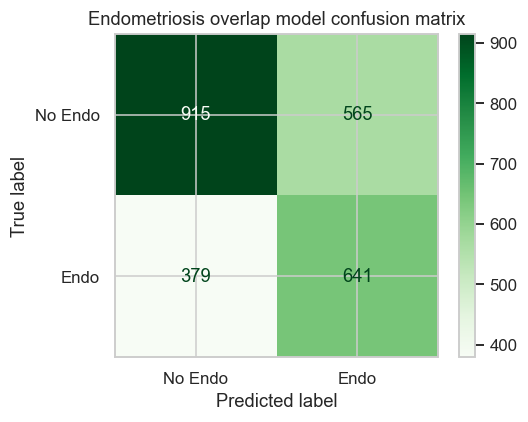

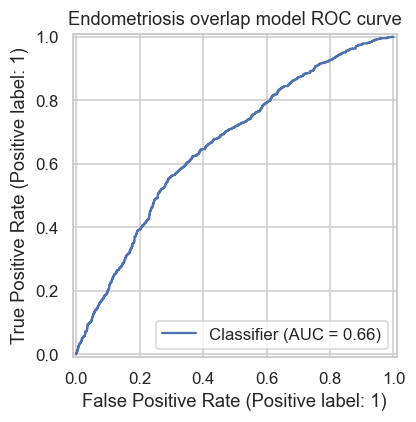

Saved: C:\Users\kex03\Downloads\biohackathon\outputs\models\endometriosis_overlap_model.joblib


In [4]:
best_endo_model.fit(X_train, y_train)
proba = best_endo_model.predict_proba(X_test)[:, 1]
pred = (proba >= threshold).astype(int)

metrics = {
    "model_name": best_name,
    "threshold": threshold,
    "threshold_source": "cv_oof_training",
    "roc_auc": roc_auc_score(y_test, proba),
    "recall": recall_score(y_test, pred),
    "specificity": recall_score(y_test, pred, pos_label=0),
    "precision": precision_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred),
    "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
    "warning": "Synthetic data. Use only as a symptom-overlap prompt.",
}

with open(METRIC_DIR / "endometriosis_holdout_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

display(metrics)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["No Endo", "Endo"], cmap="Greens", ax=ax)
ax.set_title("Endometriosis overlap model confusion matrix")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "endometriosis_confusion_matrix.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax)
ax.set_title("Endometriosis overlap model ROC curve")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "endometriosis_roc_curve.png", dpi=160)
plt.show()

artifact = {
    "model": best_endo_model,
    "model_name": best_name,
    "features": features,
    "target": TARGET,
    "threshold": threshold,
    "threshold_source": "cv_oof_training",
    "metrics": metrics,
    "notes": "Synthetic endometriosis overlap model. Use only to prompt differential workup.",
}

artifact_path = MODEL_DIR / "endometriosis_overlap_model.joblib"
joblib.dump(artifact, artifact_path)
print("Saved:", artifact_path)


## Example Overlap Flag Function


In [5]:
def endometriosis_overlap_flag(age, menstrual_irregularity, chronic_pain_level, hormone_level_abnormality, infertility, bmi):
    row = pd.DataFrame([{
        "age": age,
        "menstrual_irregularity": menstrual_irregularity,
        "chronic_pain_level": chronic_pain_level,
        "hormone_level_abnormality": hormone_level_abnormality,
        "infertility": infertility,
        "bmi": bmi,
    }])
    probability = best_endo_model.predict_proba(row[features])[:, 1][0]
    if probability >= threshold:
        label = "Endometriosis-overlap pattern: consider broader differential workup."
    else:
        label = "No strong endometriosis-overlap pattern from this simple module."
    return probability, label

endometriosis_overlap_flag(
    age=31,
    menstrual_irregularity=1,
    chronic_pain_level=8,
    hormone_level_abnormality=1,
    infertility=1,
    bmi=24,
)


(np.float64(0.7669718066713282),
 'Endometriosis-overlap pattern: consider broader differential workup.')